![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings

#### Further processing and analysis of ventilator parameters in recording `AT000001 - AT002100`

This notebook import the preprocessed ventilator data from pickle archive and analyses all the ventilator parameter data and alarms data obtained with **0.5Hz sampling rate** from the Fabian ventilators at the Cerny neonatal transport service. It exports desrciptive statistics into Excel files and the further processed data as pickle archive.

- Ventilator recordings for at least 5 minutes: **1788 cases**
- Only keep ventilator data for cases where clinical data is also available: **1703 cases**

The data processed and analysed in this Notebook were collected by the **Neonatal Emergency and Transport Service of the Peter Cerny Foundation**, Budapest, Hungary

**Author: Dr Gusztav Belteki**

### 1. Import the required libraries and set options

In [5]:
import IPython
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import os
import sys
import pickle

from pandas import Series, DataFrame
from datetime import datetime, timedelta
from matplotlib import dates

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 300)
pd.set_option('mode.chained_assignment', None) 

# This is to turn off a warning message which is given when read_Excel() imports '.xlsx' files
import warnings
warnings.simplefilter("ignore")

In [6]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]
pandas version: 2.3.2
matplotlib version: 3.10.6
NumPy version: 1.26.4
IPython version: 9.5.0


### 2. List and set the working directory and the directory to write out data

In [8]:
# Name of the external hard drive
DRIVE = 'GB_1'

# Directory on external drive to read the clinical from
DIR_READ = os.path.join(os.sep, 'Volumes', DRIVE, 'Ventilator_data', 'Fabian_new', 'fabian_patient_data_all_new')

# Path to project folder containing ventilation research results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Folder to export the result of analysis
DIR_WRITE = os.path.join(PATH, 'ventilation_fabian_new', 'Analyses')
os.makedirs(DIR_WRITE, exist_ok = True)

# Folder on a USB stick to export data to and to import processed data exported by other Notebooks
DATA_DUMP = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new',)
os.makedirs(DATA_DUMP, exist_ok = True)

In [9]:
DIR_READ, DIR_WRITE, DATA_DUMP

('/Volumes/GB_1/Ventilator_data/Fabian_new/fabian_patient_data_all_new',
 '/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new/Analyses',
 '/Volumes/GB_1/data_dump/fabian_new')

### 3. Import pickle archives of ventilator data

At least 5 minutes of ventilator data is avaiable in these cases

In [11]:
tags = ['1_150', '151_300', '301_450', '451_600', '601_750', '751_900', '901_1050', '1051_1200', '1201_1350', '1351_1500',
        '1501_1650', '1651_1800', '1801_1950', '1951_2100',]

In [12]:
%%time

data_pars = {}
for tag in tags:
    with open(os.path.join(DATA_DUMP, f'data_pars_{tag}.pickle'), 'rb') as handle:
        dta = pickle.load(handle)
    data_pars.update(dta)

# Total number of ventilator recordings which are >=5 minutes
len(data_pars)

CPU times: user 11.6 s, sys: 1.81 s, total: 13.4 s
Wall time: 13.7 s


1788

In [13]:
# Import clinical data
with open(os.path.join(DATA_DUMP, 'clin_df_new.pickle'), 'rb') as handle:
    clin_df = pickle.load(handle)
len(clin_df)

1748

### 4. Limit ventilator data to cases for which clinical data is also available

In [15]:
combined = sorted(set(clin_df.index) & set(data_pars.keys()))
data_pars = {key : value for key, value in data_pars.items() if key in combined}
len(data_pars)

1703

### 5. Create a dictionary of Dataframes with measured ventilator parameters only

In [17]:
ventilator_measurements = ['PIP', 'MAP', 'PEEP', 'Ti_PSV', 'Cdyn', 'C20_C', 'R', 'MV', 'MVresp', 'VTemand', 'VTemand_resp', 'VTespon_pat', 
                           'Leak', 'RR', 'Trigger', 'VTimand', 'deltaP', 'VThf_emand', 'DCO2', 'HFOV_freq', 'FiO2', 'etCO2', 'Flow_demand', 
                           'Flow_insp', 'Flow_exp', 'TC', 'RR_CO2', 'SpO2', 'Perfusion_index', 'Pulse_rate',]

In [18]:
data_pars_measurements = {}
for case in data_pars:
    data_pars_measurements[case] = data_pars[case][ventilator_measurements].copy()

In [19]:
%%time

# Replace some uninformative fields with np.nan
repl_dct = {'not valid': np.nan, 'out of range': np.nan, 'unused': np.nan}
for case in data_pars_measurements:
    data_pars_measurements[case].replace(repl_dct, inplace = True)

CPU times: user 7.23 s, sys: 429 ms, total: 7.66 s
Wall time: 7.86 s


In [20]:
# Normalize relevant parameters to body weight
pars_per_kg = ['MV', 'VTimand', 'VTemand', 'VTespon_pat', 'VTemand_resp', 'VThf_emand', 'Cdyn']

for case in data_pars_measurements:
    for par in pars_per_kg:
        data_pars_measurements[case][f'{par}_kg'] = data_pars_measurements[case][par] / (clin_df.loc[case]['Weight'] / 1000)

In [21]:
# Normalize DCO2 to body weight
pars_per_kg2 = ['DCO2']

for case in data_pars_measurements:
    for par in pars_per_kg2:
        data_pars_measurements[case][f'{par}_kg2'] = data_pars_measurements[case][par] / (clin_df.loc[case]['Weight'] / 1000) ** 2

In [22]:
# Drop columns which only have NaN values
for case in data_pars_measurements:
    data_pars_measurements[case].dropna(axis = 1, how = 'all', inplace = True)

##### Export dictionary containing measured ventilator parameters to a pickle archive

In [24]:
with open(os.path.join(DATA_DUMP, 'data_pars_measurements_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_measurements, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 6. Create a dictionary of Dataframes with ventilator settings

There are two `Trigger_mode` parameters. After manual observation of the data and discussion with the clinical team, `Trigger_mode_2` contains the actual ventilator triggering mode

In [27]:
ventilator_settings =  ['Patient_range', 'Ventilator_mode', 'PIP_set', 'PIP_set_PSV', 
                        'PEEP_set', 'FiO2_set', 'Flow_insp_set', 'Slope_set', 'Flow_exp_set', 'Ti_set', 
                        'Te_set', 'RR_set', 'IE_I_set', 'IE_E_set', 'deltaP_set', 'Freq_set_HFOV', 
                        'MAP_set_HFOV', 'MAP_set_HFOV_recr', 'Volume_limit_set', 'VG_set',
                        'Term_criteria_PSV_set', 'Apnea_time_set', 'RR_backup_set', 'Trigger_sens_set', 
                        'Powerstate', 'Battery_rem_time', 'Battery_rem_pc', 'MV_lim_high_set', 
                        'MV_lim_low_set', 'PIP_lim_high_set', 'PEEP_lim_low_set', 'RR_lim_set', 
                        'Leakage_lim_set', 'DCO2_lim_high_set', 'DCO2_lim_low_set', 'etCO2_lim_high_set', 
                        'etCO2_lim_low_set', 'Measuring_unit_pressure_set', 'Measuring_unit_CO2_set', 
                        'O2_compensation_set', 'CO2_baropressure_set',
                        'Flow_sensor_state', 'Oxy_sensor_state', 'P_man_breath_CPAP_HFO_set', 
                        'P_man_breath_duoPAP_NCPAP_set', 'FiO2_flush_time_set', 'FiO2_flush_set',
                        'Ventilation_stopped', 'VG_state', 'Volume_limit_state', 'Ventilator_range',
                        'Trigger_mode', 'I_E_HFOV', 'Pressure_rise_control',
                        'HFO_recruitment', 'HFO_flow', 'Bias_flow', 'Trigger_mode_2', 'FOT_running', 'Leak_comp']    

In [28]:
data_pars_settings = {}

for case in data_pars:
    data_pars_settings[case] = data_pars[case][ventilator_settings].copy()

In [29]:
# Replace HFOV I:E ratio with fraction (only this parameter has such ratios)
repl_dct = {'1:1': 0.5, '1:2': 0.33, '1:3': 0.25}
for case in data_pars_settings:
    data_pars_settings[case].replace(repl_dct, inplace = True)

In [30]:
# Replace textual data with np.nan
repl_dct = {'not valid': np.nan, 'out of range': np.nan, 'unused': np.nan}
for case in data_pars_settings:
    data_pars_settings[case].replace(repl_dct, inplace = True)

In [31]:
# Normalize relevant parameters to body weight
pars_per_kg = ['Volume_limit_set', 'VG_set', 'MV_lim_high_set', 'MV_lim_low_set',]

for case in data_pars_settings:
    #print(case)
    for par in pars_per_kg:
        dta = data_pars_settings[case][par]
        # Exclude data points when the parameter was 'off'
        data_pars_settings[case][f'{par}_kg'] = dta[dta != 'off'] / (clin_df.loc[case]['Weight'] / 1000)

In [32]:
# Normalize DCO2 limits parameters to body weight square
pars_per_kg = ['DCO2_lim_high_set', 'DCO2_lim_low_set']

for case in data_pars_settings:
    for par in pars_per_kg:
        dta = data_pars_settings[case][par]
        # Exclude data points when the parameter was 'off'
        data_pars_settings[case][f'{par}_kg2'] = dta[dta != 'off'] / (clin_df.loc[case]['Weight'] / 1000) ** 2

In [33]:
# Drop columns which only have NaN values
for case in data_pars_settings:
    data_pars_settings[case].dropna(axis=1, how='all', inplace = True)

##### Export dictionary containing ventilator settings to a pickle archive

In [35]:
with open(os.path.join(DATA_DUMP, 'data_pars_settings_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_settings, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 7. Create a dictionary of Dataframes with ventilator alarms

In [37]:
ventilator_alarms = ['Alarm_susp', 'Alarm_Flat_battery', 'Alarm_Checksum_ctrl_PIC',
                     'Alarm_Checksum_monitor_PIC', 'Alarm_Safety_relay_defect',
                     'Alarm_Sens_dev_prox_pressure', 'Alarm_input_pressure_blender',
                     'Alarm_excess_pressure', 'Alarm_voltage_monit',
                     'Alarm_SPI_interface', 'Alarm_DIO2_interface',
                     'Alarm_COM_interface', 'Alarm_I2C_interface',
                     'Alarm_parallel_interface', 'Alarm_serial_tem_interface',
                     'Alarm_low_physical_memory', 'Alarm_Fan_defect',
                     'Alarm_CO2_interface', 'Alarm_blender_defect',
                     'Alarm_battery_defect', 'Alarm_input_pressure_O2_supply',
                     'Alarm_input_pressure_air_supply', 'Alarm_tube_occlusion',
                     'Alarm_patient_disconnected', 'Alarm_ETT_blocked',
                     'Alarm_flow_sensor_defect', 'Alarm_flow_sensor_clean',
                     'Alarm_flow_sensor_disconnected', 'Oxygen_sensor_defect',
                     'Oxygen_sensor_used_up', 'Oxyen_value_divergence',
                     'Alarm_O2_sensor_cal_error', 'Alarm_MV_high', 'Alarm_MV_low',
                     'Alarm_pressure_high', 'Alarm_pressure_low', 'Alarm_PEEP_high',
                     'Alarm_RR_high', 'Alarm_ETT_leak_high', 'Alarm_apnea',
                     'Alarm_DCO2_high', 'Alarm_DCO2_low', 'Alarm_etCO2_high',
                     'Alarm_etCO2_low', 'Alarm_PIP_not_reached', 'Alarm_limited_volume',
                     'Alarm_volume_not_reached', 'Alarm_power_failure',
                     'Alarm_charge_battery_60min', 'Alarm_charge_battery_30min',
                     'Alarm_charge_battery_15min', 'Alarm_nebulizer_disconnection',
                     'Alarm_nebulizer_system_error', 'Alarm_CO2_module_not_connected',
                     'Alarm_CO2_filterline_not_connected', 'Alarm_CO2_check_sampleline',
                     'Alarm_CO2_check_airway_adapter', 'Alarm_CO2_sensor_faulty',
                     'Alarm_CO2_high', 'Alarm_CO2_low', 'Alarm_PRICO_FiO2_our_of_range',
                     'Alarm_SPO2_module_not_connected', 'Alarm_SPO2_sensor_faulty',
                     'Alarm_check_SPO2_sensor', 'Alarm_SPO2_low_SIQ', 'Alarm_high_SPO2',
                     'Alarm_low_SPO2', 'Alarm_SPO2_low_PI', 'Alarm_low_PIP', ]

In [38]:
data_pars_alarms = {}

for case in data_pars:
    data_pars_alarms[case] = data_pars[case][ventilator_alarms].copy()

In [39]:
# Replace textual data with np.nan
repl_dct = {'off': np.nan, 'not valid': np.nan, 'out of range': np.nan, 'unused': np.nan}
for case in data_pars_alarms:
    data_pars_alarms[case].replace(repl_dct, inplace = True)

In [40]:
%%time

# Drop columns which only have NaN values (these alarms never went off)
for case in data_pars_alarms:
    for column in data_pars_alarms[case].columns:
        if data_pars_alarms[case][column].sum() == 0:
            del data_pars_alarms[case][column]        

CPU times: user 14.9 s, sys: 375 ms, total: 15.3 s
Wall time: 15.3 s


##### Export dictionary containing ventilator alarms to a pickle archive

In [42]:
with open(os.path.join(DATA_DUMP, 'data_pars_alarms_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_alarms, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 8. Exploratory analysis on ventilation modes in the unedited recordings

##### How many cases of the different ventilation modes occur

In [45]:
vent_modes = {}
for case in data_pars_settings:
    # Multiply by two to get the number of seconds
    vent_modes[case] = data_pars_settings[case]['Ventilator_mode'].value_counts() * 2
    
vent_modes = DataFrame(vent_modes).T
vent_modes.replace(np.nan, 0, inplace = True)

In [46]:
# Add the duration of the recordings
recording_duration = {}

for case in data_pars_settings:
    recording_duration[case] = 2 * len(data_pars_settings[case])

In [47]:
vent_modes['ventilation'] = vent_modes['IPPV']  + vent_modes['SIMV'] + vent_modes['PSV']   + vent_modes['HFO'] + \
                            vent_modes['SIPPV'] + vent_modes['SIMVPSV']
vent_modes['noninvasive'] = vent_modes['CPAP']  + vent_modes['DUOPAP'] + vent_modes['NCPAP'] + vent_modes['O2therapy']  
vent_modes['total'] = Series(recording_duration)

In [48]:
# How long was VG turned on
VG = {}
for case in data_pars_settings:
    VG[case] = sum(data_pars_settings[case]['VG_state'] == 'on') * 2
        
VG = Series(VG)
vent_modes['VG'] = VG
vent_modes.head()

Ventilator_mode,CPAP,DUOPAP,HFO,IPPV,NCPAP,O2therapy,PSV,SIMV,SIMVPSV,SIPPV,ventilation,noninvasive,total,VG
AT000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,0.0,4564.0,4592.0,0.0,4592,4538
AT000006,0.0,0.0,0.0,0.0,0.0,2492.0,0.0,0.0,0.0,0.0,0.0,2492.0,2492,0
AT000007,0.0,0.0,0.0,0.0,4800.0,0.0,0.0,0.0,0.0,0.0,0.0,4800.0,4800,0
AT000008,0.0,0.0,0.0,0.0,214.0,0.0,0.0,5376.0,0.0,0.0,5376.0,214.0,5590,3724
AT000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1224.0,0.0,4736.0,5960.0,0.0,5960,5244


In [49]:
print('SIMV:', sum(vent_modes['SIMV'] > 0))
print('SIPPV:', sum(vent_modes['SIPPV'] > 0))
print('SIMVPSV:', sum(vent_modes['SIMVPSV'] > 0))
print('PSV:', sum(vent_modes['PSV'] > 0))
print('HFO:', sum(vent_modes['HFO'] > 0))
print('IPPV:', sum(vent_modes['IPPV'] > 0))
print('NCPAP:', sum(vent_modes['NCPAP'] > 0))
print('CPAP:', sum(vent_modes['CPAP'] > 0))
print('DUOPAP:', sum(vent_modes['DUOPAP'] > 0))
print('O2therapy:', sum(vent_modes['O2therapy'] > 0))
print('ventilation:', sum(vent_modes['ventilation'] > 0))
print('VG on:', sum(vent_modes['VG'] > 0))
print('noninvasive:', sum(vent_modes['noninvasive'] > 0))
print('total:', len(vent_modes))

SIMV: 619
SIPPV: 620
SIMVPSV: 180
PSV: 13
HFO: 226
IPPV: 50
NCPAP: 1031
CPAP: 70
DUOPAP: 260
O2therapy: 305
ventilation: 1160
VG on: 689
noninvasive: 1353
total: 1703


In [50]:
# How many seconds of each ventilation mode in total ?
total_duration = DataFrame(vent_modes.sum(axis = 0), columns = ['duration (seconds)'])
total_duration

,duration (seconds)
Ventilator_mode,
CPAP,13412.0
DUOPAP,488024.0
HFO,534756.0
IPPV,34074.0
NCPAP,2379380.0
O2therapy,587516.0
PSV,14034.0
SIMV,1491060.0
SIMVPSV,296588.0


##### Export Dataframes containing ventilator modes to Excel files and pickle archives

In [52]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'ventilation_modes_unedited_new.xlsx'))
vent_modes.to_excel(writer, 'vent_modes')
total_duration.to_excel(writer, 'total_duration')
writer.close()

In [53]:
with open(os.path.join(DATA_DUMP, 'vent_modes_unedited_new.pickle'), 'wb') as handle:
    pickle.dump(vent_modes, handle, protocol=pickle.HIGHEST_PROTOCOL)

##### Export data about ventilation modes in the unedited recordings as text files

In [102]:
%%time

for case in data_pars_settings:
    a = data_pars_settings[case]
    
    o2therapy = len(a[a['Ventilator_mode'] == 'O2therapy'])
    ncpap = len(a[a['Ventilator_mode'] == 'NCPAP'])
    duopap = len(a[a['Ventilator_mode'] == 'DUOPAP'])
    simv = len(a[a['Ventilator_mode'] == 'SIMV'])
    ippv = len(a[a['Ventilator_mode'] == 'IPPV'])
    sippv = len(a[a['Ventilator_mode'] == 'SIPPV'])
    simvpsv = len(a[a['Ventilator_mode'] == 'SIMVPSV'])
    psv = len(a[a['Ventilator_mode'] == 'PSV'])
    hfo = len(a[a['Ventilator_mode'] == 'HFO'])
    vg_on = len(data_pars[case][data_pars[case]['VG_state'] == 'on'])
  
    fileout = open(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_vent_info_unedited.txt'), 'w')
    # Sampling is 0.5 Hz, hence multiply it by 2 to get the number of seconds
    fileout.write('O2 therapy: %d sec \n' % (o2therapy * 2))
    fileout.write('NCPAP:      %d sec \n' % (ncpap * 2))
    fileout.write('DUOPAP:     %d sec \n' % (duopap * 2))
    fileout.write('IPPV:       %d sec \n' % (ippv * 2))
    fileout.write('SIPPV:      %d sec \n' % (sippv * 2))
    fileout.write('SIMV:       %d sec \n' % (simv * 2))
    fileout.write('SIMVPSV:    %d sec \n' % (simvpsv * 2))
    fileout.write('PSV:        %d sec \n' % (psv * 2))
    fileout.write('HFO:        %d sec \n\n' % (hfo * 2))
    fileout.write('VG on:      %d sec \n' % (vg_on * 2))
    
    fileout.close()

### 9. Generate graphs about unedited recordings

Generated graphs for 1703 recordings. 

CPU times: user 1min 28s, sys: 6.63 s, total: 1min 34s
Wall time: 1min 40s


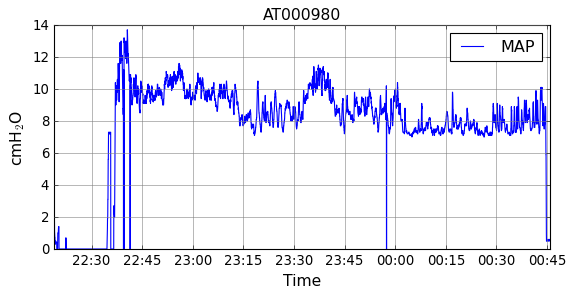

In [57]:
%%time

par = 'MAP'; dim = 'cmH$_2$O'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements:

    try:
        fig = plt.figure()
        fig.set_size_inches(8, 4)
        fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
        ax = fig.add_subplot(1, 1, 1)
        data_pars_measurements[case][par].plot(ax = ax, label = par, x_compat = True)
        ax.set_xlabel('Time', size = 14, color = 'black')
        ax.set_ylabel(dim, size = 14, color = 'black')
        ax.set_title(case,  size = 14, color = 'black')
        ax.legend()
        ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
        majorFmt = dates.DateFormatter('%H:%M')  
        ax.xaxis.set_major_formatter(majorFmt)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
        ax.tick_params(which = 'both', labelsize=12)
            
        fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_unedited_{par}.{filetype}'), 
            dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

        if case != 'AT000980':
            plt.close()
        n+=1
            
    except Exception as e:
        #print(f'{case} does not have MAP')
        #print(e)
        plt.close()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 1139 recordings. 

CPU times: user 1min 4s, sys: 6.22 s, total: 1min 10s
Wall time: 1min 15s


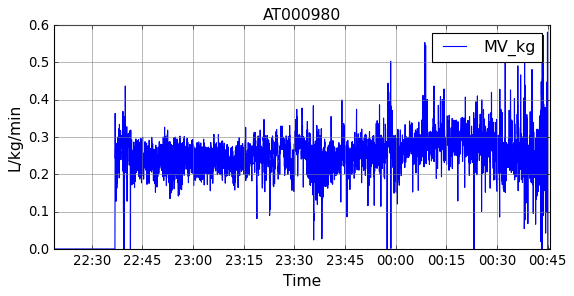

In [58]:
%%time

par = 'MV_kg'; dim = 'L/kg/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements:

    try:
        fig = plt.figure()
        fig.set_size_inches(8, 4)
        fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
        ax = fig.add_subplot(1, 1, 1)
        data_pars_measurements[case][par].plot(ax = ax, label = par, x_compat = True)
        ax.set_xlabel('Time', size = 14, color = 'black')
        ax.set_ylabel(dim, size = 14, color = 'black')
        ax.set_title(case,  size = 14, color = 'black')
        ax.legend()
        ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')

        majorFmt = dates.DateFormatter('%H:%M')  
        ax.xaxis.set_major_formatter(majorFmt)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
        ax.tick_params(which = 'both', labelsize=12)
            
        fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_unedited_{par}.{filetype}'), 
            dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,)
        n+=1

        if case != 'AT000980':
            plt.close()
        
    except Exception as e:
        #print(f'{case} does not have ventilation')
        #print(e)
        plt.close()

print(f'Generated graphs for {n} recordings.', '\n')